# Adult Census Income — explaining a classifier's probability

- Author: [givasile](https://givasile.github.io/)
- Runtime: ~5 min
- Description: the variance ledger on a **classifier** — effector explains
  the predicted probability `P(income > 50K)` of a gradient-boosted model on
  the [Adult census dataset](https://archive.ics.uci.edu/dataset/2/adult)
  (UCI id 2). The probability surface turns out to be deeply interactive:
  global curves reproduce 72%, and it takes **four** splits — conditioned
  on `age`, `marital-status`, `capital-gain` and `education-num` — to
  reach 86%.

The dataset: 45,222 census records (after dropping rows with missing
values); the target is whether yearly income exceeds $50K. The model is a
`HistGradientBoostingClassifier`; effector sees only its
`predict_proba(...)[:, 1]` — a numpy → numpy function like any other.

In [1]:
import effector
import numpy as np

np.random.seed(21)

## Load the data

`effector.datasets.AdultIncome` drops `fnlwgt` (a sampling weight) and
`education` (duplicated by `education-num`), encodes the categorical columns
to integer codes with the level names recorded, and buckets levels rarer
than 50 rows into `"Other"` — a level that rare can vanish from a train
split, leaving the schema promising a category the data never shows.

In [2]:
data = effector.datasets.AdultIncome()

print(f"X_train: {data.x_train.shape}, X_test: {data.x_test.shape}")
print("-" * 66)
for i, name in enumerate(data.feature_names):
    cats = data.category_names[i]
    extra = f"{len(cats)} levels" if cats else "numeric"
    print(f"x_{i:<2} {name:16s} [{data.feature_types[i]:10s}] {extra}")
print("-" * 66)
print(f"target: {data.target_name}, base rate: {data.y_train.mean():.1%}")

X_train: (36177, 12), X_test: (9045, 12)
------------------------------------------------------------------
x_0  age              [continuous] numeric
x_1  workclass        [nominal   ] 7 levels
x_2  education-num    [ordinal   ] numeric
x_3  marital-status   [nominal   ] 7 levels
x_4  occupation       [nominal   ] 14 levels
x_5  relationship     [nominal   ] 6 levels
x_6  race             [nominal   ] 5 levels
x_7  sex              [nominal   ] 2 levels
x_8  capital-gain     [continuous] numeric
x_9  capital-loss     [continuous] numeric
x_10 hours-per-week   [continuous] numeric
x_11 native-country   [nominal   ] 25 levels
------------------------------------------------------------------
target: income>50K, base rate: 24.9%


## Fit a classifier

In [3]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

clf = HistGradientBoostingClassifier(random_state=21).fit(data.x_train, data.y_train)
print(f"test AUC = {roc_auc_score(data.y_test, clf.predict_proba(data.x_test)[:, 1]):.3f}")

test AUC = 0.925


## Explain

Class labels are not a regression surface — effector explains a per-class
probability. `effector.adapters.classifier_proba` wraps
`predict_proba(...)[:, class_]` into the numpy → numpy callable every engine
expects. From here on, everything — curves, heterogeneity, the ledger — is
in probability units.

In [4]:
model_forward = effector.adapters.classifier_proba(clf, class_=1)
effector.adapters.check(model_forward, data.x_train)

schema = effector.Schema(
    feature_names=data.feature_names,
    feature_types=data.feature_types,
    category_names=data.category_names,
    target_name=data.target_name,
)

## The one-click report

In [5]:
report = effector.explain(
    data=data.x_train,
    model=model_forward,
    y=data.y_train,
    schema=schema,
    method="pdp",
    nof_instances=5000,
)
report.show()
report.to_html("report_adult_income_pdp.html")  # open in browser

[effector] global effects reproduce 72.5% of the model's variance; with subregions, 86.0%

PDP report — target: income>50K
data: 5,000 instances × 12 features (4 continuous · 7 nominal · 1 ordinal) — target income>50K
model output: mean 0.249, std 0.309, range [0.000225, 0.999] · accuracy 0.879 (on this subsample)
explained variance: global effects (GAM) 72.5%
  + split education-num (on age, capital-gain, marital-status) → 80.4% (+7.9 pts, heter 0.069→0.040)
  + split capital-gain (on age, education-num, marital-status) → 83.2% (+2.9 pts, heter 0.254→0.162)
  + split capital-loss (on age, capital-gain, marital-status) → 85.0% (+1.7 pts, heter 0.108→0.084)
  + split hours-per-week (on age, capital-gain, marital-status) → 86.0% (+1.0 pts, heter 0.064→0.045)
  rejected: age (on hours-per-week, marital-status) — +0.7 pts, below the 1.0-pt threshold
  rejected: relationship (on age, marital-status) — +0.3 pts, below the 1.0-pt threshold
-----------------------------------------------------

/home/givasile/github/packages/effector/effector/report.py:422: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/home/givasile/github/packages/effector/effector/visualization.py:357: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


## The decision sequence

Unlike the single-interaction stories (medical costs, airfoil), this
probability surface needs a *chain*: four splits, each with a real marginal
gain, and each conditioning on the same social cast — `age`,
`marital-status`, `education-num`.

In [6]:
pdp = effector.PDP(data.x_train, model_forward, schema=schema, nof_instances=5000)
chain = pdp.select_regions()
chain.show()

GAM: R2 = 0.725
  + education-num regions (on age, capital-gain, marital-status) -> R2 = 0.804 (+7.9 pts)
  + capital-gain regions (on age, education-num, marital-status) -> R2 = 0.832 (+2.9 pts)
  + capital-loss regions (on age, capital-gain, marital-status) -> R2 = 0.850 (+1.7 pts)
  + hours-per-week regions (on age, capital-gain, marital-status) -> R2 = 0.860 (+1.0 pts)
  x age regions skipped (below_threshold, +0.7 pts)
  x relationship regions skipped (below_threshold, +0.3 pts)


## Look at the headline split: `capital-gain`

The global `capital-gain` curve has the dataset's famous cliff: predicted
probability jumps sharply once reported capital gains pass a few thousand
dollars (almost nobody with meaningful capital gains earned under $50K in
the 1994 census). The split shows the cliff is *conditional* — its height
depends on who is standing at it.

In [7]:
parts = pdp.find_regions("capital-gain", finder="best")
parts.show()



Feature 8 - Full partition tree:
🌳 Full Tree Structure:
───────────────────────
capital-gain 🔹 [id: 0 | heter: 0.25 | inst: 5000 | w: 1.00]
    marital-status = Married-civ-spouse 🔹 [id: 1 | heter: 0.23 | inst: 2319 | w: 0.46]
        education-num = 13.00 🔹 [id: 2 | heter: 0.17 | inst: 436 | w: 0.09]
        education-num ∈ {1.00, 2.00, 3.00, …} (15 levels) 🔹 [id: 3 | heter: 0.22 | inst: 1883 | w: 0.38]
    marital-status ∈ {Divorced, Married-spouse-absent, Never-married, …} (6 levels) 🔹 [id: 4 | heter: 0.21 | inst: 2681 | w: 0.54]
        age < 20.65 🔹 [id: 5 | heter: 0.08 | inst: 304 | w: 0.06]
        age ≥ 20.65 🔹 [id: 6 | heter: 0.12 | inst: 2377 | w: 0.48]
--------------------------------------------------
Feature 8 - Statistics per tree level:
🌳 Tree Summary:
─────────────────
Level 0🔹heter: 0.25
    Level 1🔹heter: 0.22 | 🔻0.04 (14.10%)
        Level 2🔹heter: 0.16 | 🔻0.06 (25.85%)




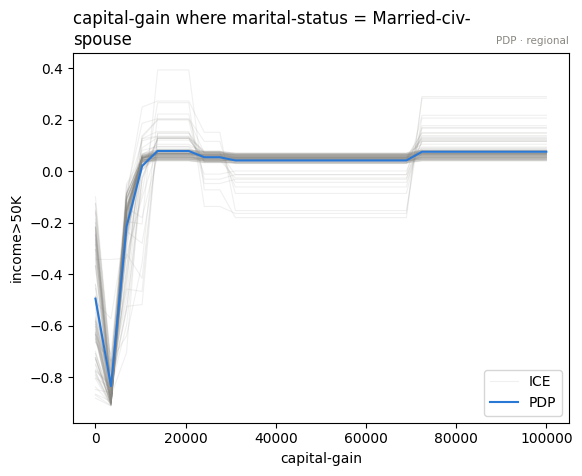

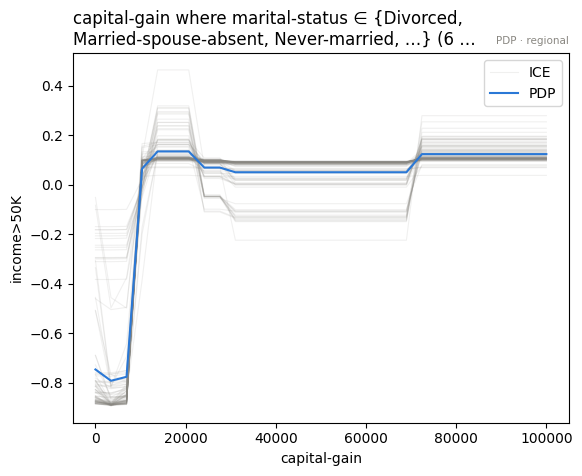

In [8]:
for r in parts:
    if r.level == 1:
        parts.plot(r.idx, centering=True)

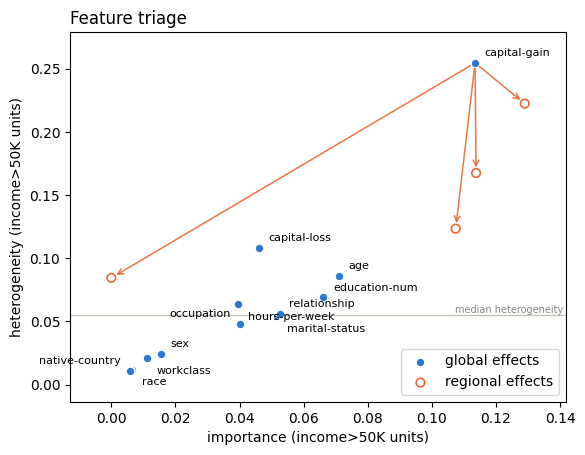

In [9]:
effector.plot_triage(pdp, partitions={"capital-gain": parts})

## Conclusion

- Classification needs no special machinery: wrap `predict_proba` with
  `adapters.classifier_proba` and every verb — curves, regions, the ledger —
  works in probability units.
- The ledger read is qualitatively different from the single-interaction
  datasets: **72% → 86% takes four stacked splits**, because the model's
  probability surface interacts along several axes at once
  (`education-num`, `capital-gain`, `capital-loss`, `hours-per-week` — all
  conditioned on `age` / `marital-status` / `capital-gain`).
- For a model like this, the final CALM — a small collection of
  region-conditional curves — is a far more faithful mental model than any
  single set of global curves.

## Cross-method sanity check

The one-liner `effector.explain` with every engine this notebook's model
supports. A gradient-boosted tree is piecewise-constant, so derivative-scale
methods (RHALE, DerPDP) have no meaningful gradients to work with and are out
of scope here; PDP, ALE and SHAP-DP cover the output-scale reads. Where
methods disagree — ranking, accepted splits, R² — that is a property of the
data/model worth a closer look, not an error.


In [10]:
# === cross-method sweep: effector.explain on every applicable engine ======
sweep_reports = {}
for _m in ["pdp", "ale", "shapdp"]:
    _kw = {"nof_instances": 300} if _m == "shapdp" else {"nof_instances": 5000}
    print(f"--- {_m} " + "-" * 50)
    sweep_reports[_m] = effector.explain(
        data.x_train, model_forward, y=data.y_train, method=_m, schema=schema, **_kw
    )
    sweep_reports[_m].to_html(f"report_adult_income_{_m}.html")

print()
print(f"{'method':<8} {'ranking (plotted)':<52} {'GAM R2':>8} {'final R2':>9}  splits")
for _m, _r in sweep_reports.items():
    _rank = " > ".join(fr.name for fr in _r.features)
    _ev = _r.explained_variance
    _sp = "; ".join(f"{s['name']} on {s['on']}" for s in _ev["stages"]) or "none"
    print(f"{_m:<8} {_rank:<52} {_ev['gam_r2']:>7.1%} {_ev['regional_r2']:>8.1%}  {_sp}")


--- pdp --------------------------------------------------


[effector] global effects reproduce 72.5% of the model's variance; with subregions, 86.0%


/home/givasile/github/packages/effector/effector/report.py:422: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


/home/givasile/github/packages/effector/effector/visualization.py:357: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


--- ale --------------------------------------------------


...

/home/givasile/github/packages/effector/effector/report.py:422: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


--- shapdp --------------------------------------------------


[effector] global effects reproduce 64.2% of the model's variance; with subregions, 73.5%


/home/givasile/github/packages/effector/effector/report.py:422: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()



method   ranking (plotted)                                      GAM R2  final R2  splits
pdp      capital-gain > age > education-num > capital-loss > relationship > hours-per-week   72.5%    86.0%  education-num on age, capital-gain, marital-status; capital-gain on age, education-num, marital-status; capital-loss on age, capital-gain, marital-status; hours-per-week on age, capital-gain, marital-status
ale      capital-gain > education-num > capital-loss > relationship > marital-status > hours-per-week   75.3%    82.9%  education-num on age, capital-gain, marital-status; hours-per-week on age, capital-gain, relationship
shapdp   capital-gain > education-num > relationship > marital-status > age > capital-loss   64.2%    73.5%  capital-gain on marital-status, workclass; education-num on marital-status; capital-loss on education-num, relationship
